# Phase 1 — Data Exploration
Analyse the 3 datasets after running `python scripts/run_phase1.py`.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DOMAINS = ['amazon_reviews', 'tweets', 'financial_news']
SPLITS  = ['train', 'val', 'test']
LABEL_NAMES = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']

## 1. Load all splits

In [2]:
dfs = {}
for domain in DOMAINS:
    frames = []
    for split in SPLITS:
        p = Path(f'../data/splits/{domain}/{split}.csv')
        if p.exists():
            df = pd.read_csv(p)
            df['split'] = split
            frames.append(df)
    if frames:
        dfs[domain] = pd.concat(frames, ignore_index=True)
        print(f'{domain}: {len(dfs[domain]):,} rows')

amazon_reviews: 25,000 rows
tweets: 22,403 rows
financial_news: 11,924 rows


## 2. Class distribution per domain

C:\Users\spinz\AppData\Local\Temp\ipykernel_10968\3195989834.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(LABEL_NAMES, rotation=30, ha='right', fontsize=8)
C:\Users\spinz\AppData\Local\Temp\ipykernel_10968\3195989834.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(LABEL_NAMES, rotation=30, ha='right', fontsize=8)
C:\Users\spinz\AppData\Local\Temp\ipykernel_10968\3195989834.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(LABEL_NAMES, rotation=30, ha='right', fontsize=8)


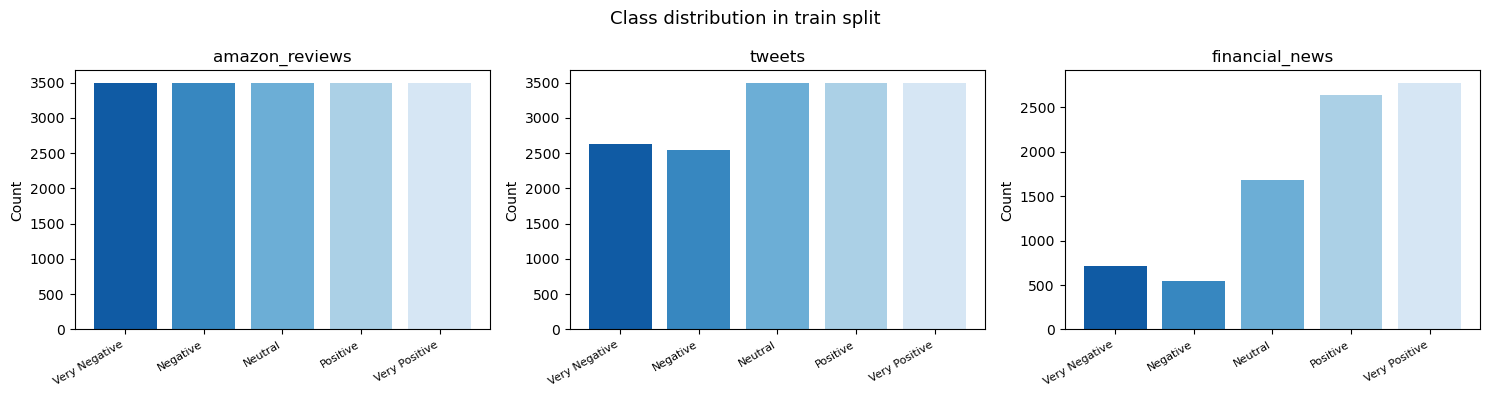

In [3]:
fig, axes = plt.subplots(1, len(dfs), figsize=(15, 4))
for ax, (domain, df) in zip(axes, dfs.items()):
    counts = df[df['split'] == 'train']['label'].value_counts().sort_index()
    ax.bar(LABEL_NAMES, counts.values, color=sns.color_palette('Blues_r', 5))
    ax.set_title(domain)
    ax.set_xticklabels(LABEL_NAMES, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Count')
plt.suptitle('Class distribution in train split', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Text length distribution

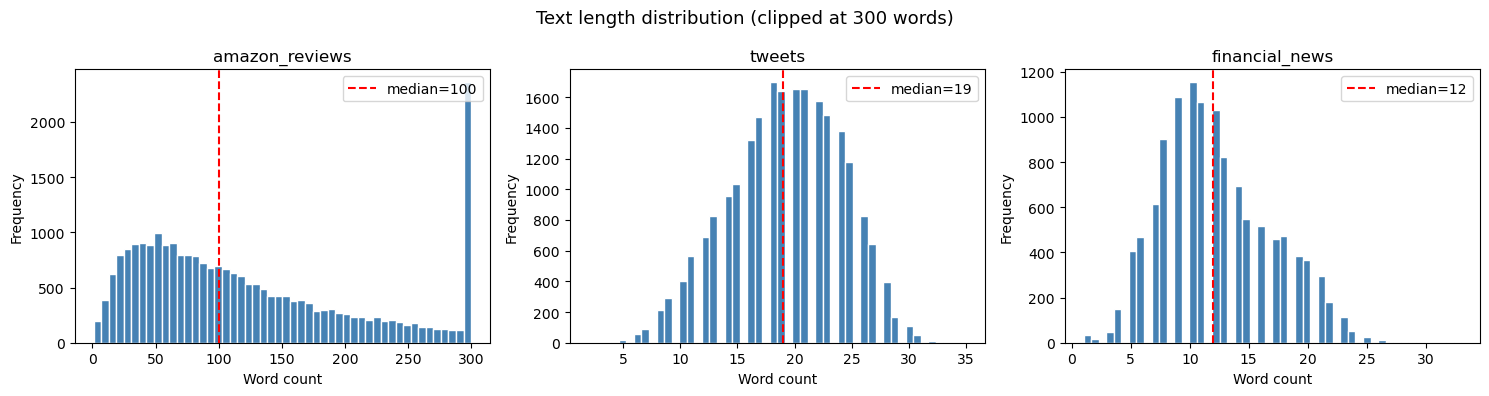

In [4]:
fig, axes = plt.subplots(1, len(dfs), figsize=(15, 4))
for ax, (domain, df) in zip(axes, dfs.items()):
    lengths = df['text'].str.split().str.len()
    ax.hist(lengths.clip(upper=300), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(domain)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Frequency')
    ax.axvline(lengths.median(), color='red', linestyle='--', label=f'median={lengths.median():.0f}')
    ax.legend()
plt.suptitle('Text length distribution (clipped at 300 words)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Split ratio check

In [5]:
for domain, df in dfs.items():
    total = len(df)
    for split in SPLITS:
        n = (df['split'] == split).sum()
        print(f'{domain:20s} {split:5s}: {n:6,}  ({n/total:.1%})')
    print()

amazon_reviews       train: 17,499  (70.0%)
amazon_reviews       val  :  3,750  (15.0%)
amazon_reviews       test :  3,751  (15.0%)

tweets               train: 15,682  (70.0%)
tweets               val  :  3,360  (15.0%)
tweets               test :  3,361  (15.0%)

financial_news       train:  8,346  (70.0%)
financial_news       val  :  1,789  (15.0%)
financial_news       test :  1,789  (15.0%)



## 5. Null and duplicate check

In [6]:
for domain, df in dfs.items():
    nulls = df['text'].isnull().sum()
    dups  = df['text'].duplicated().sum()
    print(f'{domain}: nulls={nulls}, duplicates={dups}')

amazon_reviews: nulls=0, duplicates=0
tweets: nulls=0, duplicates=0
financial_news: nulls=0, duplicates=0
